# Cat-Dog Image Classifier

### Importing Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory  # pyright: ignore
from tensorflow.keras import layers, Sequential # pyright: ignore
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # pyright: ignore
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

I0000 00:00:1786977329.606986    1098 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786977330.251452    1098 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786977332.149157    1098 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Loading Images

In [2]:
train = image_dataset_from_directory(
    '../Data/catdog/training_set',
    validation_split = 0.2,
    subset = 'training',
    seed = 123,
    image_size = (180, 180),
    batch_size = 32
)

validation = image_dataset_from_directory(
    '../Data/catdog/training_set',
    validation_split = 0.2,
    subset = 'validation',
    seed = 123,
    image_size = (180, 180),
    batch_size = 32
)


test = image_dataset_from_directory(
    '../Data/catdog/test_set',
    seed = 123,
    image_size = (180, 180),
    batch_size = 32
)

Found 8000 files belonging to 2 classes.
Using 6400 files for training.


I0000 00:00:1786977335.051646    1098 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 8000 files belonging to 2 classes.
Using 1600 files for validation.
Found 2000 files belonging to 2 classes.


### Scaling and augmenting 

In [3]:
augmenting = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
rescale = layers.Rescaling(1./255)

### Building The Model

In [4]:
model = Sequential([
    augmenting,
    rescale,
    layers.Conv2D(32,3, activation= 'relu', input_shape = (180,180,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3, activation= 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,3, activation= 'relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation= 'relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation= 'sigmoid')
])

/home/harsh/Work/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compiling the model

In [5]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

### Training the Model

In [6]:
early_stop = EarlyStopping(monitor= 'val_loss', patience= 5, restore_best_weights= True)
checkpoint = ModelCheckpoint('best_model.keras', monitor= 'val_accuracy', save_best_only= True)

history = model.fit(
    train,
    validation_data  = validation,
    epochs = 40,
    callbacks = [early_stop, checkpoint]
)

Epoch 1/40


/home/harsh/Work/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786977339.872329    1510 cuda_dnn.cc:461] Loaded cuDNN version 92400


200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.5255 - loss: 0.7041 - val_accuracy: 0.5294 - val_loss: 0.6891
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.5559 - loss: 0.6835 - val_accuracy: 0.5319 - val_loss: 0.6853
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5927 - loss: 0.6694 - val_accuracy: 0.5894 - val_loss: 0.6859
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6330 - loss: 0.6489 - val_accuracy: 0.6356 - val_loss: 0.6645
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6720 - loss: 0.6102 - val_accuracy: 0.6669 - val_loss: 0.6122
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.6900 - loss: 0.5809 - val_accuracy: 0.7306 - val_loss: 0.5699
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.7058 - loss: 0.5694 - val_accuracy: 0.6562 - val_loss: 0.6991
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.7337 - loss: 0.5373 - val_accuracy: 0.75

### Testing 

In [7]:
test_loss, test_accuracy = model.evaluate(test)
print(f"Test Accuracy : {test_accuracy}")
print(f"Test loss : {test_loss}")

 1/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8750 - loss: 0.4585

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8045 - loss: 0.4260
Test Accuracy : 0.8044999837875366
Test loss : 0.42603346705436707


### Visualizing training curve

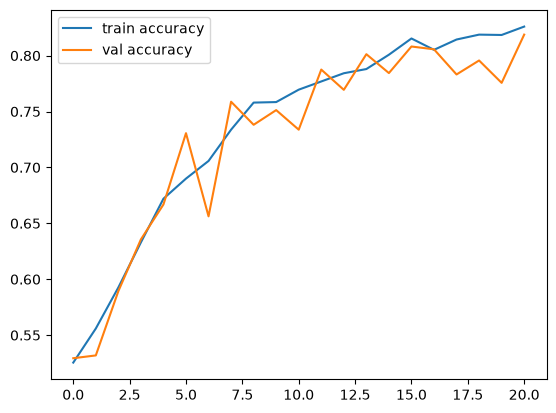

In [8]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

### Confusion matrix

In [9]:
y_true = np.concatenate([y for x, y in test], axis = 0)
y_pred = (model.predict(test) >0.5).astype(int).flatten()

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
[[470 530]
 [409 591]]
              precision    recall  f1-score   support

           0       0.53      0.47      0.50      1000
           1       0.53      0.59      0.56      1000

    accuracy                           0.53      2000
   macro avg       0.53      0.53      0.53      2000
weighted avg       0.53      0.53      0.53      2000

